<a href="https://colab.research.google.com/github/NbtKmy/politologie_japanologie/blob/main/BlueSky_analyse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Texte aus Bluesky maschinell analysieren


In diesem Notebook analysieren wir die Posten in Bluesky auf Japanisch mit folgenden Libraries:

- [janome](https://github.com/mocobeta/janome) - apanese morphological analysis engine written in pure Python.
- [japanize-matplotlib](https://github.com/uehara1414/japanize-matplotlib) - Ermöglicht japanische Schriften in Matplotlib
- [asari](https://github.com/Hironsan/asari) - Asari is a Japanese sentiment analyzer implemented in Python.



In [1]:
!pip install atproto pandas matplotlib janome japanize-matplotlib asari

In [2]:
from atproto import Client
import pandas as pd
import matplotlib.pyplot as plt
from janome.tokenizer import Tokenizer
from collections import Counter
from google.colab import userdata

## User-Information für die API-Abfrage eingeben und die Query formulieren

In [3]:
HANDLE = userdata.get("BLUESKY_HANDLE")
PASSWORD = userdata.get("BLUESKY_PASSWORD")
QUERY = "政治"
COUNT = 100


## Einloggen

In [4]:
client = Client()
client.login(HANDLE, PASSWORD)

ProfileViewDetailed(did='did:plc:z4gbcpr5mbkblvaybyj7lb4o', handle='nbtkmy.bsky.social', associated=ProfileAssociated(activity_subscription=ProfileAssociatedActivitySubscription(allow_subscriptions='followers', py_type='app.bsky.actor.defs#profileAssociatedActivitySubscription'), chat=None, feedgens=0, labeler=False, lists=0, starter_packs=0, py_type='app.bsky.actor.defs#profileAssociated'), avatar='https://cdn.bsky.app/img/avatar/plain/did:plc:z4gbcpr5mbkblvaybyj7lb4o/bafkreifbycx2uctdi434fqhko3nunethgikaaj4ib4gyawm2cty5cb7vkm@jpeg', banner='https://cdn.bsky.app/img/banner/plain/did:plc:z4gbcpr5mbkblvaybyj7lb4o/bafkreigqbemylzaqto7i6jmqagykj2daah3nrq6yh2lhd3tlnlafcblcim@jpeg', created_at='2023-12-22T17:06:17.158Z', debug=None, description='A liaison librarian in Zurich', display_name='Nobutake Kamiya', followers_count=64, follows_count=151, indexed_at='2024-01-26T03:41:05.174Z', joined_via_starter_pack=None, labels=[], pinned_post=None, posts_count=13, pronouns=None, status=None, veri

# Abfrage abschicken

In [5]:
params = {'q': QUERY, 'limit': COUNT}
search_results = client.app.bsky.feed.search_posts(params=params)


# Nur die Texte aus dem Ergebnis nehmen

Die einzelnen Texte in den Posten sind hier in einem Listen-Objekt gespeichert.

In [6]:
import re

posts_text = [post.record.text for post in search_results.posts]

# URLs in den Posten werden hier nicht berücksichtigt
cleaned_posts_text = []
for text in posts_text:
    cleaned_text = re.sub(r"https?://\S+|www\.\S+", '', text)
    cleaned_posts_text.append(cleaned_text)

posts_text = cleaned_posts_text

# Morphologische Analyse mit Janome

Die Texte werden in die Wörter zerlegt. Danach werden nur die Normen ausgelesen.

In [7]:
# Wörter herausfinden
t = Tokenizer()
words = []

# Stop words
stop_words = ["こと", "もの", "ため", "よう", "ところ", "はず", "わけ", "これ", "それ", "あれ", "どれ", "..."]

for text in posts_text:
    tokens = t.tokenize(text)
    words.extend([token.surface for token in tokens if token.part_of_speech.startswith("名詞") and token.surface not in stop_words])

# Wörter zählen

In [8]:

count_dict = Counter(words)
# Wörter aus einem Buchstabe oder das Wort der Abfrage ausser Betracht ziehen
filtered_count = {k: v for k, v in count_dict.items() if len(k) > 1 and k != QUERY}
df = pd.DataFrame(filtered_count.items(), columns=["Word", "Count"]).sort_values(by="Count", ascending=False)



# Visualisierung

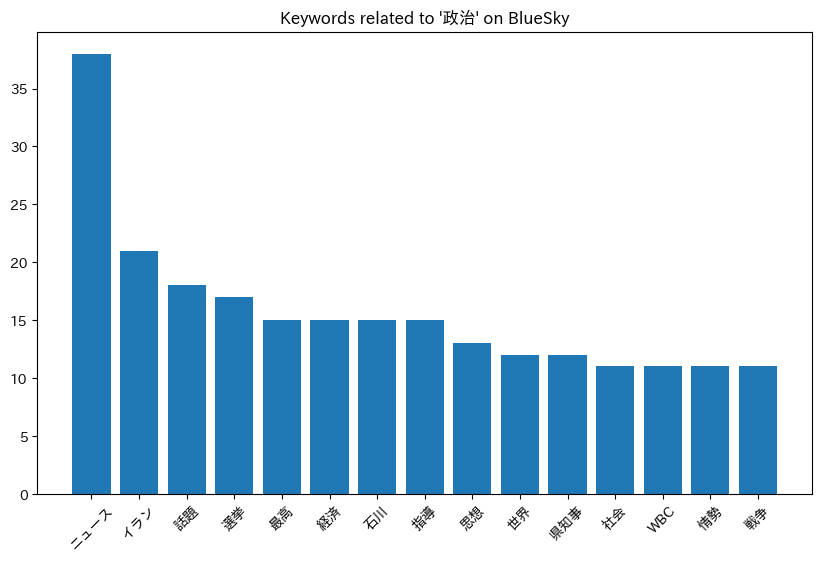

In [9]:

import japanize_matplotlib # This line imports and configures Japanese fonts

plt.figure(figsize=(10, 6))
plt.bar(df["Word"].head(15), df["Count"].head(15))
plt.title(f"Keywords related to '{QUERY}' on BlueSky")


plt.xticks(rotation=45)
plt.show()

In [10]:
print(f"\nPosten (Auszug)\n{posts_text[:3]}")


Posten (Auszug)
['「社会的な善性というのは人為的に作られるものだから、常に教育は必要だ」という、いわゆる「性悪説」は、実は立憲政治とも符合する部分は多いです。その一方で、孟子の「性善説」の土台となる「惻隠の情」は立憲政治の土台となるべきヒューマニズムと、「天命」思想は社会契約論とも通じるとも言えます。\nja.wikipedia.org/wiki/%E5%AD%...', '> 総務省が公開した２０２２年分の政治資金収支報告書によると、家具大手「ニトリホールディングス」（札幌市）は、計２７政治団体のパーティー券を合計３６２０万円購入していました。\n\n政治資金規正法はパーティ券の購入を上限150万円としているが、開催回数を増やすことで実質的に規制が無意味化しているという', '政治が趣味に影響してくるわかりやすい例']


# Sentimental Analysis mit Asari

Die Python-Library "asari" gibt folgende Antwort zurück:

```
{
  "text" : "広告多すぎる♡",
  "top_class" : "negative",
  "classes" : [ {
    "class_name" : "positive",
    "confidence" : 0.09130180181262026
  }, {
    "class_name" : "negative",
    "confidence" : 0.9086981981873797
  } ]
}
```


In [12]:
from asari.api import Sonar
sonar = Sonar()

In [13]:
sentiments = []
for text in posts_text:
    res = sonar.ping(text)
    # Der Wert in top_class positiv oder negativ?
    sentiments.append(res['top_class'])

In [14]:
sentiment_counts = Counter(sentiments)
labels = sentiment_counts.keys()
values = sentiment_counts.values()

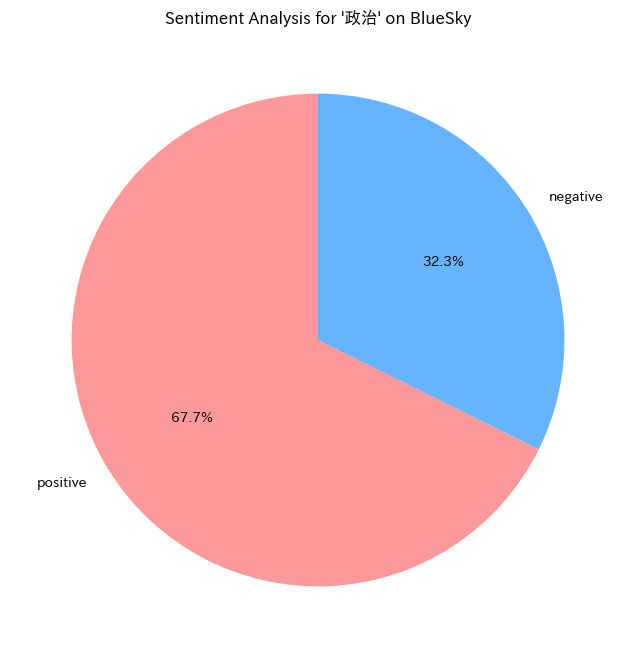

In [15]:
plt.figure(figsize=(8, 8))
plt.pie(values, labels=labels, autopct='%1.1f%%', startangle=90, colors=['#ff9999','#66b3ff'])
plt.title(f"Sentiment Analysis for '{QUERY}' on BlueSky")
plt.show()

In [17]:
neg_posts = [t for t, s in zip(posts_text, sentiments) if s == 'negative']
print(f"\n【Als negativ beurteilte Posten】\n{neg_posts[:2]}")


【Als negativ beurteilte Posten】
['有料記事🎁10日 10:04まで全文読めます。\n\n“逆説的だが、権力の外に置かれてきたからこそ女性たちは軍事力や政治的支配ではない「創造的」な方法で実験するしかない（『三ギニー』170ページ）。そしてウルフのように、まさに芸術的な営為において力を発揮する”\n\ndigital.asahi.com/articles/ASS...', '企業献金を受けている政党や政治家、政治資金パーティーをやっている政党や政治家、全員ダメです。お金を出している企業や業界の言いなりになりますから。国民のための政治なんて出来るわけないです。']
